## Business Understanding
# 📊 Insurance Claim Cases Analysis

- Historical data of **insurance claim cases** (~1,300+ cases)
- Each case involves **bodily injury insurance claims** from a specific region
- Some claimants **hire an attorney**, *some do not*
- Hiring an attorney usually increases the settlement amount, which affects:
  - *The cost to the insurance company*
  - *The profitability of the insurer*

---

## 🎯 Goals of the Insurance Company

- **Predict** the likelihood that a claimant will hire an attorney  
- **Understand** which types of customers are more likely to do so  

---

## 🏦 Business Strategy

- **Design better policies**  
- **Target different customer segments differently**


## 1. Import Necessary Libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


## 2. Import Dataset

In [2]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation
# ⚙️ Data Preparation for Logistic Regression

## 1. Data Collection
- Gather relevant features (independent variables) and the target (dependent variable).
- Ensure the target is **binary** (e.g., 0 = No, 1 = Yes).

---

## 2. Data Cleaning
- Handle **missing values** (drop, impute, or replace).
- Remove **duplicates**.
- Correct **inconsistent formats** (dates, categories, strings).

---

## 3. Feature Engineering
- Encode categorical variables:
  - **Label Encoding** (for ordinal categories).
  - **One-Hot Encoding** (for nominal categories).
- Create new features if they add predictive power.

---

## 4. Data Transformation
- Standardize or normalize numerical features if scales differ.
- Apply **log transformation** for skewed variables.

---

## 5. Train-Test Split
- Split dataset into **training** and **testing** sets (e.g., 70/30 or 80/20).
- Optionally use **cross-validation** for robust evaluation.

---

## 6. Multicollinearity Check
- Use **correlation matrix** or **Variance Inflation Factor (VIF)**.
- Drop or combine highly correlated features.

---

## 7. Balance the Target Variable
- If classes are imbalanced:
  - Apply **SMOTE (Synthetic Minority Oversampling Technique)**.
  - Use **undersampling/oversampling**.
  - Adjust **class weights** in the model.

---

## 8. Model Assumptions & Diagnostics
- Ensure **linear relationship** between predictors and log-odds.
- Check for **outliers** that may distort results.
- Verify **independence of observations**.

---

## 9. Final Dataset
- Confirm all variables are numeric and properly scaled.
- Ensure target variable is binary (0/1).
- Ready for logistic regression training.


### 4.1 Data Cleaning

#### Since customername and casenum not helpful for predicattion we can remove it from input

In [6]:
claimants_data.dropna(inplace = True)

In [9]:
1340-1096

244

In [17]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [7]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

## 4.2 Seperate your inputs and Outputs

In [8]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"],axis = 1,)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [9]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20,shuffle=True, random_state=34,)
#Random_state=34 mean whenever you shuffle it will produce same set of result
# Why it help ful we don want each time different shuffled data, while practising it

In [77]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


In [84]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
627,1.0,1.0,0.0,40.0,6.337
1125,1.0,1.0,0.0,37.0,4.609
1124,1.0,1.0,0.0,46.0,0.730
1025,1.0,1.0,0.0,38.0,3.406
481,1.0,1.0,0.0,70.0,0.566
...,...,...,...,...,...
658,0.0,1.0,0.0,14.0,4.479
1257,0.0,1.0,0.0,7.0,0.453
1015,1.0,0.0,0.0,69.0,3.110
1114,1.0,1.0,0.0,0.0,7.169


In [12]:
logistic_model = LogisticRegression()

## 6. Model Training

In [13]:
without_decision_tree_model = logistic_model.fit(X_train,y_train)

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
dt_model = DecisionTreeClassifier()

In [16]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 7. Model Testing

### Training Data

In [17]:
y_pred_train = dt_model.predict(X_train)
y_pred_train

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,

### Test Data

In [18]:
y_pred_test = dt_model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0])

## 8. Model Evaluation

In [37]:
#Before going to evaulation metrics just checking with accuracy scores between x_train and x_test, but this is not sufficiet to make judement, that's why we go for evaulation metrics

In [19]:
#Training Accuracy
ac_predict_data = without_decision_tree_model.predict(X_train)
#Test Accuracy
test_predict_data = without_decision_tree_model.predict(X_test)

In [35]:
accuracy_score(y_test, test_predict_data)

0.6818181818181818

In [36]:
accuracy_score(y_train, ac_predict_data)

0.708904109589041

In [39]:
#Almost same

In [20]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### 8.1 Training Data's Evaluation Metrics

#### With the help confusion matrix we can come to know, what is true postive prediction an false positive predication.
* If False postive prediction(mean actual showing zero but test showing one) it is ok for client
*  but still we have to see how we can reduce FPP
*  And False Negative Prediction is danger , that we must see

In [110]:
print(confusion_matrix(y_train, y_pred_train))

[[453   0]
 [  4 419]]


In [28]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       453
           1       1.00      0.99      1.00       423

    accuracy                           1.00       876
   macro avg       1.00      1.00      1.00       876
weighted avg       1.00      1.00      1.00       876



### ROC Curve - Receiver Operating Characteristics

##### AUC - Area Under this Curve

0.9952718676122931


Text(0, 0.5, 'True Positive Rate')

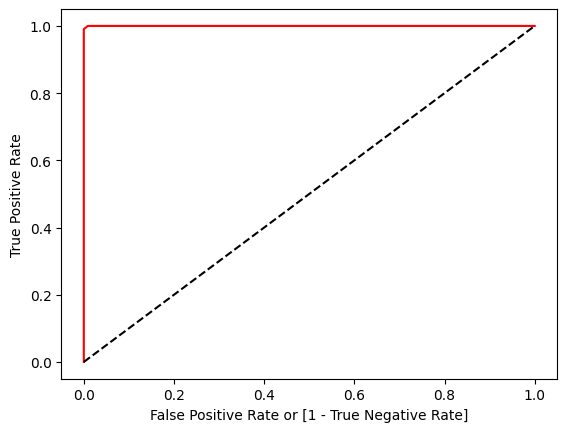

In [29]:
fpr, tpr, thresholds = roc_curve(y_train, dt_model.predict_proba (X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### 8.2 Test Data's Evaluation Metrics

In [30]:
accuracy_score(y_test, y_pred_test)

0.6045454545454545

In [31]:
print(confusion_matrix(y_test, y_pred_test))

[[75 50]
 [37 58]]


In [32]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.67      0.60      0.63       125
           1       0.54      0.61      0.57        95

    accuracy                           0.60       220
   macro avg       0.60      0.61      0.60       220
weighted avg       0.61      0.60      0.61       220



0.6052631578947368


Text(0, 0.5, 'True Positive Rate')

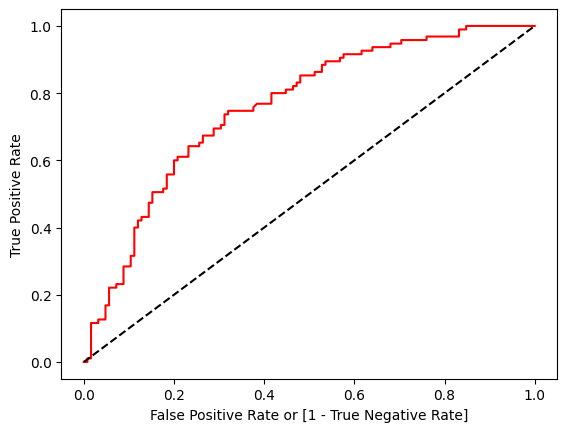

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba (X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

In [34]:
#Since both x_train, ytrain and x_test, y_test both give similar restult 70% the model will give correct result

# 📊 Understanding ROC Curve (Train vs Test)

We plotted two ROC curves:

1. **Training ROC (x_train, y_train_predicted)**  
   - The curve goes high toward the top-left corner.  
   - This means the model learned the training data very well.  
   - But if it looks *too perfect*, it might be memorizing (overfitting).

2. **Testing ROC (x_test, y_test_predicted)**  
   - The curve is still above the diagonal line (random guessing).  
   - This shows the model performs well on new, unseen data.  
   - If it dropped close to the diagonal, the model would not generalize well.

**ROC CURVE MEANS**
- Think of your model as a smart robot that decides whether something is “positive” or “negative.”
The ROC curve shows how good that robot is at making those decisions.

- The x-axis is False Positive Rate (FPR) — how often the robot says “positive” when it’s wrong.

- The y-axis is True Positive Rate (TPR) — how often the robot correctly says “positive.”

-Each point on the curve shows what happens when you change the robot’s “strictness” (the threshold).

---

## 🎯 What AUC Means
- **AUC = Area Under the Curve**  
- It’s like a score between 0.5 and 1.0:  
  - **1.0 → Perfect model**  
  - **0.5 → Random guessing**  
  - **0.8–0.9 → Very good model**  
  - **0.6–0.7 → Okay, needs improvement**

So, AUC tells us how good the model is overall at separating classes.

---

## 🧒 Analogy
Think of it like a school bell:  
- If it rings too often → false alarms (false positives).  
- If it rarely rings → you miss class (false negatives).  
The ROC curve shows how well the bell balances.  
The AUC is the final score of how reliable the bell is.


## 9. Model Deployment

In [39]:
from pickle import dump

In [40]:
dump(logistic_model,open("claimaints.pkl","wb"))

## THE END!!